## **Generating Dataset Type D (Using Ewa25)**

In [ ]:
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
# Import Necessarry Dependencies
#-------------------------------------------------------------------------------------------------------------------------------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from numpy.linalg import pinv
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # For 3D plots
import seaborn as sns
import pandas as pd
import random
from sklearn.svm import LinearSVC

> **Synthetic Dataset Type (d) - 2 Concentric Classes *(like Figure 1b in [Ewa25]).***

<img src="https://drive.google.com/uc?id=1Xru8EXduh0ozSnUitQdX6736Rp6e1jhL" width="300">

> **(Old) Version 1 of Dataset D using Two Circles**

DATA: Using synthetic concentric classes: [0, 1] | Q = 2 | L = 3 

----------- VISUALIZING CONCENTRIC DATA (FILLED) -----------



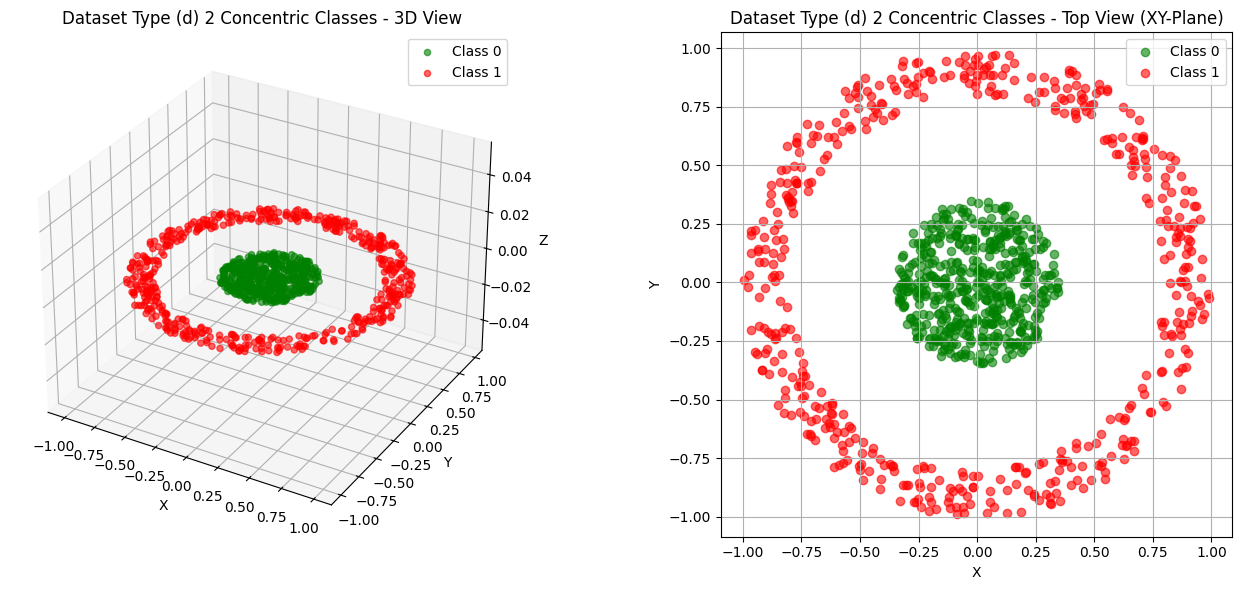

In [ ]:
def generate_concentric_data():
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Select Classes and Setup
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    selected_digits = [0, 1]
    Q = len(selected_digits)
    L = Q + 1

    print(f"DATA: Using synthetic concentric classes: {selected_digits} | Q = {Q} | L = {L} \n")

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Create Synthetic Data (Filled Disk + Ring)
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    # Generates points evenly inside a filled disk
    def generate_filled_disk(radius=0.35, n_samples=500):
        r = np.sqrt(np.random.uniform(0, radius**2, n_samples)) # Random radius (more points near center)
        theta = np.random.uniform(0, 2 * np.pi, n_samples) # Random angle from 0 to 2π
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        return np.column_stack([x, y]) # Shape: (n_samples, 2)

    # Generates points evenly in a ring (hollow disk)
    def generate_ring(inner=0.8, outer=1.0, n_samples=500):
        r = np.sqrt(np.random.uniform(inner**2, outer**2, n_samples)) # Random radius between inner and outer
        theta = np.random.uniform(0, 2 * np.pi, n_samples) # Random angle from 0 to 2π
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        return np.column_stack([x, y]) # Shape: (n_samples, 2)


    X0 = generate_filled_disk()
    X1 = generate_ring()

    y0 = np.zeros(X0.shape[0])
    y1 = np.ones(X1.shape[0])

    X = np.vstack([X0, X1]) # Shape: (1000, 2)
    y = np.concatenate([y0, y1]) # Shape: (1000,)
    X = np.hstack([X, np.zeros((X.shape[0], 1))]) # Lift to ℝ³: z = 0 → Shape: (1000, 3)

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Preprocess Data
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Visualize Generated Data
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------

    print("----------- VISUALIZING CONCENTRIC DATA (FILLED) -----------\n")

    fig = plt.figure(figsize=(14, 6))

    # 3D View
    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    colors = ['green', 'red']
    for label in np.unique(y):
        ax1.scatter(X[y == label, 0], X[y == label, 1], X[y == label, 2],
                    color=colors[int(label)], label=f'Class {int(label)}', alpha=0.6)
    ax1.set_title("Dataset Type (d) 2 Concentric Classes - 3D View")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.legend()

    # Top-down 2D View
    ax2 = fig.add_subplot(1, 2, 2)
    for label in np.unique(y):
        ax2.scatter(X[y == label, 0], X[y == label, 1],
                    color=colors[int(label)], label=f'Class {int(label)}', alpha=0.6)
    ax2.set_title("Dataset Type (d) 2 Concentric Classes - Top View (XY-Plane)")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.legend()
    ax2.set_aspect('equal')
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        'Q': Q,
        'X': X, 'y': y,
        'X_train': X_train, 'y_train': y_train,
        'train_loader': train_loader,
        'test_loader': test_loader
    }

_ = generate_concentric_data()

> **(New) Version 2 of Dataset D using Vectors & Simplez**

DATA: Using synthetic simplex-enclosed class (Corollary 3.2): [0, 1] | Q=2 | L=3
----------- VISUALIZING SIMPLEX-ENCLOSED DATA (Corollary 3.2) -----------



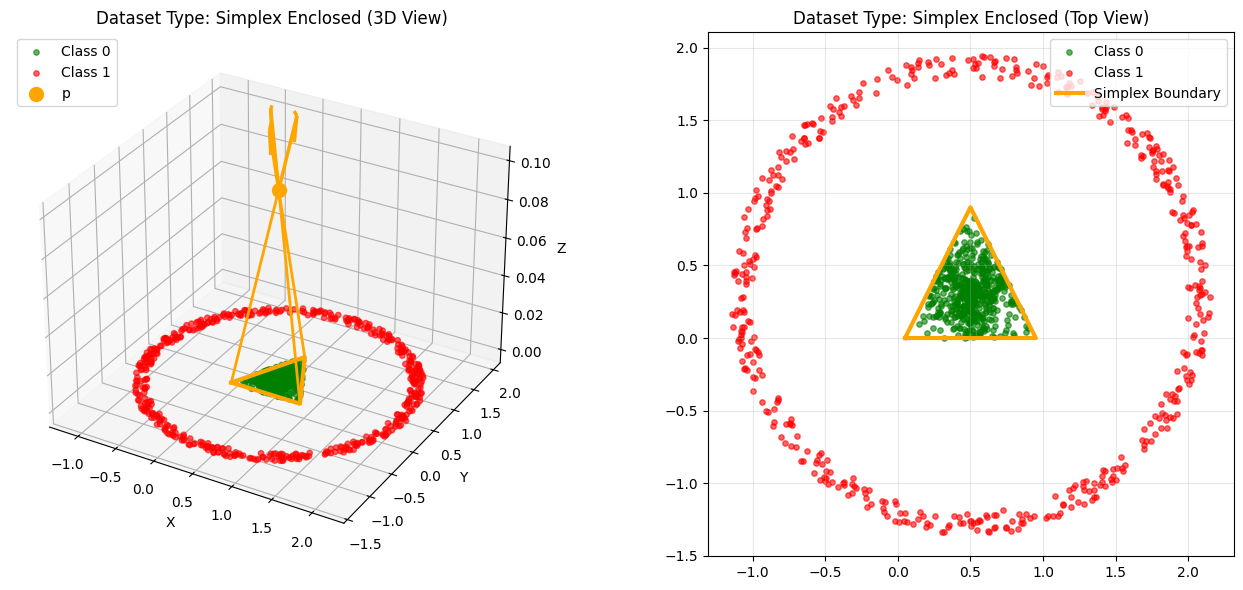


Simplex Vertices S3 (3D):
 s1 = [0.05 0.   0.  ]
 s2 = [0.95 0.   0.  ]
 s3 = [0.5 0.9 0. ]

Point p:
 p = [0.5 0.3 0.1]

Vectors v_i = p - s_i:
 v1 = [0.45 0.3  0.1 ]
 v2 = [-0.45  0.3   0.1 ]
 v3 = [ 0.  -0.6  0.1]


In [ ]:
def generate_simplex_data():
    """
    Corollary 3.2 Dataset Construction:
      X1 lies strictly inside the simplex
      X2 lies strictly outside the simplex
      Geometry is lifted to R^{n+1} using as stated in the proof
    """

    selected_digits = [0,1]
    Q = len(selected_digits)
    L = Q + 1

    print(f"DATA: Using synthetic simplex-enclosed class (Corollary 3.2): {selected_digits} | Q={Q} | L={L}")

    S = np.array([
        [0.05, 0.00],
        [0.95, 0.00],
        [0.50, 0.90],
    ], dtype=float)

    centroid = S.mean(axis=0)
    S3 = np.c_[S, np.zeros(3)]

    # "choose p a positive distance away from the hyperplane" — Cor.3.2
    p = np.array([centroid[0], centroid[1], 0.1], dtype=float)

    # "v_i := p - s_i" — Eq (3.11)
    v1, v2, v3 = p - S3[0], p - S3[1], p - S3[2]


    # Guarantees "X1 ⊂ S" and strictly interior per Corollary 3.2
    M = S.T

    def barycentric(x):
        A = np.linalg.lstsq(M, x.T, rcond=None)[0].T
        s = A.sum(axis=1, keepdims=True)
        s[s == 0] = 1.0
        return A/s

    def strictly_inside_simplex(x, eps=1e-9):
        return np.all(barycentric(x) > eps, axis=1)

    # Class 0 = X1 inside S
    n0 = 500

    def sample_inside_simplex(n, shrink=0.06):
        a = np.random.rand(n,3)
        a /= a.sum(axis=1, keepdims=True)
        pts = a @ S
        mask = strictly_inside_simplex(pts)
        if not np.all(mask):
            pts = pts[mask]
            while pts.shape[0] < n:
                need = n - pts.shape[0]
                a2 = np.random.rand(need,3)
                a2 /= a2.sum(axis=1, keepdims=True)
                extra = (1-shrink)*(a2@S) + shrink*centroid
                extra = extra[strictly_inside_simplex(extra)]
                pts = np.vstack([pts, extra])[:n]
        return pts

    X0_2d = sample_inside_simplex(n0)

    # Class 1 = X2 outside S
    n1 = 500

    def sample_outside_simplex(n, ring_inner_scale=2.5, ring_outer_scale=2.75):
        pts = []
        rad_vertices = np.linalg.norm(S - centroid, axis=1)
        r_in = rad_vertices.max()*ring_inner_scale
        r_out = rad_vertices.max()*ring_outer_scale

        while len(pts) < n:
            m = max(2000, 4*(n-len(pts)))
            theta = np.random.uniform(0,2*np.pi,m)
            r = np.sqrt(np.random.uniform(r_in**2,r_out**2,m))
            cand = np.column_stack([centroid[0]+r*np.cos(theta),
                                    centroid[1]+r*np.sin(theta)])

            # inside = strictly_inside_simplex(cand)
            # keep = cand[~inside]
            # pts.extend(keep.tolist())

            pts.extend(cand.tolist())
        return np.array(pts[:n])

    X1_2d = sample_outside_simplex(n1)

    y0 = np.zeros(X0_2d.shape[0], dtype=int)  # Class X1 inside simplex
    y1 = np.ones(X1_2d.shape[0], dtype=int)   # Class X2 outside simplex

    X2d = np.vstack([X0_2d, X1_2d])
    y = np.concatenate([y0, y1])

    # "include the data into R^{n+1} via ι := ι(n,n+1)" — Corollary 3.2 proof
    X = np.hstack([X2d, np.zeros((X2d.shape[0], 1))])


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Visualize Generated Dataset + simplex + p + (v1,v2,v3)
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    print("----------- VISUALIZING SIMPLEX-ENCLOSED DATA (Corollary 3.2) -----------\n")

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    colors = ['green', 'red']
    for label in np.unique(y):
        ax1.scatter(X[y == label, 0], X[y == label, 1], X[y == label, 2],
                    color=colors[int(label)], label=f'Class {int(label)}', alpha=0.6, s=15)

    cyc = np.vstack([S3, S3[0]])
    ax1.plot(cyc[:, 0], cyc[:, 1], cyc[:, 2], color='orange', lw=3, zorder=10)


    ax1.scatter([p[0]], [p[1]], [p[2]], c='orange', s=100, label='p')
    arrow_scale = 0.20

    for s_i, v in zip(S3, [v1, v2, v3]):
        v_norm = v / (np.linalg.norm(v) + 1e-12)

        ax1.plot([s_i[0], p[0]],
                [s_i[1], p[1]],
                [s_i[2], p[2]],
                color='orange', linewidth=2, zorder=10)

        ax1.quiver(p[0], p[1], p[2],
                  v_norm[0], v_norm[1], v_norm[2],
                  length=arrow_scale,
                  arrow_length_ratio=0.15,
                  color='orange',
                  linewidth=2.5,
                  zorder=11)

    ax1.set_title("Dataset Type: Simplex Enclosed (3D View)")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.legend(loc='upper left')

    ax2 = fig.add_subplot(1, 2, 2)
    for label in np.unique(y):
        ax2.scatter(X[y == label, 0], X[y == label, 1],
                    color=colors[int(label)], alpha=0.6, s=15,
                    label=f'Class {int(label)}')

    cyc2 = np.vstack([S, S[0]])
    ax2.plot(cyc2[:, 0], cyc2[:, 1],
            color='orange', lw=3, zorder=10,
            label='Simplex Boundary')

    ax2.set_aspect('equal')
    ax2.set_title("Dataset Type: Simplex Enclosed (Top View)")
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right')


    plt.tight_layout()
    plt.show()

    print("\nSimplex Vertices S3 (3D):")
    for i, s_i in enumerate(S3):
        print(f" s{i+1} = {s_i}")

    print("\nPoint p:")
    print(" p =", p)

    print("\nVectors v_i = p - s_i:")
    for i, v in enumerate([v1, v2, v3]):
        print(f" v{i+1} = {v}")

    return {
        'Q': Q,
        'X': X, 'y': y,
        'X_train': X_train, 'y_train': y_train,
        'train_loader': train_loader,
        'test_loader': test_loader
    }

_ = generate_simplex_data()

## **Main Pipeline (w/ Cones and Truncation Maps)**

In [ ]:
def run_main_pipeline(dataset_type, *loss_thresholds,
                      plateau_tol=1e-6, max_epochs=1500, patience=20, lr=3e-3, momentum=0.9,
                      loss_threshold=None):

    # Normalize thresholds into a list
    thresholds = []
    if loss_threshold is not None and not loss_thresholds:
        # keyword path: could be scalar or iterable
        try:
            # treat iterables (list/tuple/numpy array)
            thresholds = list(loss_threshold)
        except TypeError:
            thresholds = [float(loss_threshold)]
    else:
        # positional path (one or many)
        if loss_thresholds:
            thresholds = [float(t) for t in loss_thresholds]
        else:
            thresholds = [1e-3]  # default

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Configure Based On Which Dataset Was Chosen
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    if dataset_type == 'd1':
        print('You have chosen: (d) 2 Concentric Classes v1')
        data = generate_concentric_data()
    elif dataset_type == 'd2':
        print('You have chosen: (d) 2 Concentric Classes v2')
        data = generate_simplex_data()
    else:
        raise ValueError("Invalid dataset_type. Choose from {'a', 'b', 'c', 'd'}")

    Q = data['Q']
    X = data['X']
    y = data['y']
    X_train = data['X_train']
    y_train = data['y_train']
    train_loader = data['train_loader']
    test_loader = data['test_loader']

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Model definition (unchanged)
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    input_dim = 3
    hidden_dims = [3] * Q
    output_dim = Q

    class TruncationNet(nn.Module):
        def __init__(self, input_dim=input_dim, hidden_dims=hidden_dims, output_dim=output_dim):
            super().__init__()
            dims = [input_dim] + hidden_dims + [output_dim]
            self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)])
        def forward(self, x):
            for layer in self.layers[:-1]:
                x = F.relu(layer(x))
            return self.layers[-1](x)

    # --- training helper (unchanged) ---
    def train_until_threshold(model, train_loader, Q,
                              loss_threshold=1e-3,     # stop when mean MSE ≤ this
                              max_epochs=500,          # hard cap
                              patience=20,             # tolerate this many non-improving epochs
                              plateau_tol=1e-6,        # min improvement to count as “better”
                              lr=3e-3, momentum=0.9):
        def one_hot(labels, k):
            return F.one_hot(labels, num_classes=k).float()

        opt = optim.SGD(model.parameters(), lr=lr, momentum=momentum)
        crit = nn.MSELoss()

        best = float('inf')
        no_improve = 0
        final_loss = None

        for epoch in range(1, max_epochs + 1):
            model.train()
            total, denom = 0.0, 0
            for data, target in train_loader:
                opt.zero_grad(set_to_none=True)
                out = model(data)
                tgt = one_hot(target, Q)
                loss = crit(out, tgt)
                loss.backward()
                opt.step()
                bs = target.size(0)
                total += loss.item() * bs
                denom += bs

            epoch_loss = total / denom
            final_loss = epoch_loss

            if epoch == 1 or epoch % 10 == 0:
                print(f"Epoch {epoch:3d} | loss={epoch_loss:.6f}")

            if epoch_loss <= loss_threshold:
                print(f"[Early stop: threshold] epoch {epoch} | loss {epoch_loss:.6f} ≤ {loss_threshold}")
                break

            if best - epoch_loss <= plateau_tol:
                no_improve += 1
                if no_improve >= patience:
                    print(f"[Early stop: plateau] epoch {epoch} | loss {epoch_loss:.6f}")
                    break
            else:
                best = epoch_loss
                no_improve = 0

        return final_loss

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # For each threshold: train → test → compute cones & truncations → draw a row
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    titles = ["Original Data"] + [f"Truncated Layer {i+1}" for i in range(Q)] + ["Final Output"]
    num_subplots = Q + 2
    nrows = len(thresholds)

    fig = plt.figure(figsize=(5 * num_subplots, 5 * nrows))

    for r, thr in enumerate(thresholds):
        print(f"\n================ RUN {r+1}/{nrows} | loss_threshold={thr} | plateau_tol={plateau_tol} ================\n")

        # fresh model per run
        model = TruncationNet()

        print('\n----------- BEGIN TRAINING MODEL -----------\n')
        final_loss = train_until_threshold(model, train_loader, Q,
                                           loss_threshold=thr,
                                           max_epochs=max_epochs,
                                           patience=patience,
                                           plateau_tol=plateau_tol,
                                           lr=lr, momentum=momentum)
        print(f"Final MSE Loss: {final_loss:.6f}")
        print('\n----------- END TRAINING MODEL -----------')

        # --- Testing ---
        print('----------- BEGIN TESTING MODEL -----------\n')
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for data_b, target_b in test_loader:
                output_b = model(data_b)
                pred = output_b.argmax(dim=1)
                correct += (pred == target_b).sum().item()
                total += target_b.size(0)
        test_acc = correct / total
        print(f"Test Accuracy: {test_acc * 100:.2f}%")
        print('\n----------- END TESTING MODEL -----------\n')

        # --- cumulative parameters ---
        Ws, bs_ = [], []
        for layer in model.layers:
            Ws.append(layer.weight.detach().clone())
            bs_.append(layer.bias.detach().clone())

        W_cum_chain, b_cum_chain = [], []
        for ell in range(len(Ws)):
            if ell == 0:
                Wcum = Ws[0]
                bcum = bs_[0]
            else:
                Wcum = Ws[ell] @ W_cum_chain[-1]
                btemp = 0
                for k in range(ell):
                    chain = Ws[ell]
                    for j in range(ell-1, k, -1):
                        chain = chain @ Ws[j]
                    btemp += chain @ bs_[k]
                bcum = btemp + bs_[ell]
            W_cum_chain.append(Wcum)
            b_cum_chain.append(bcum)
        print('- NOTE: FINISHED WITH CALCULATING CUMULATIVE PARAMETERS \n')

        # --- cones (optional prints preserved) ---
        def compute_cones(W_cum, b_cum, residual_tol=1e-4):
            cones = []
            for ell, (W, b) in enumerate(zip(W_cum, b_cum)):
                if hasattr(W, 'detach'): W = W.detach().cpu().numpy()
                if hasattr(b, 'detach'): b = b.detach().cpu().numpy()
                W_pinv = np.linalg.pinv(W)
                p = -W_pinv @ b
                m = W.shape[0]
                edges, edge_residuals = [], []
                for i in range(m):
                    ei = np.zeros(m); ei[i] = 1
                    vi = W_pinv @ ei
                    edges.append(vi)
                    residual = np.linalg.norm(W @ vi - ei)
                    edge_residuals.append(residual)
                cones.append({'base': p, 'edges': edges})

                # checks
                print(f"\n=== Layer {ell+1} Cone Checks ===")
                rank = np.linalg.matrix_rank(W)
                rows, _ = W.shape
                print(f"Rank(W) = {rank} | Should be full row rank = {rows}")
                if rank == rows: print("✅ Surjective check passed, it is full row rank")
                else:           print("⚠️ Not surjective")
                base_residual = np.linalg.norm(W @ p + b)
                if base_residual <= residual_tol:
                    print(f"✅ Base point residual ||Wp + b|| = {base_residual:.2e} (OK)")
                else:
                    print(f"⚠️ Base point residual ||Wp + b|| = {base_residual:.2e} exceeds tolerance")
                edge_residuals = np.array(edge_residuals)
                num_failed_edges = np.sum(edge_residuals > residual_tol)
                mean_edge_residual = np.mean(edge_residuals)
                if num_failed_edges == 0:
                    print(f"✅ All edge checks passed | Failing: {num_failed_edges}/{m} | Mean residual: {mean_edge_residual:.2e}")
                else:
                    print(f"⚠️ Some edge residuals exceed tolerance | Failing: {num_failed_edges}/{m} | Mean residual: {mean_edge_residual:.2e}")
                print(f"------------------")
                if rank == rows and base_residual <= residual_tol and num_failed_edges == 0:
                    print("✅ Lemma 2.1 conditions are met")
                else:
                    print("⚠️ Lemma 2.1 conditions are not met")
            print('\n----------- FINISHED COMPUTING CONES -----------\n')
            return cones

        cones = compute_cones(W_cum_chain, b_cum_chain)

        # --- truncation chain ---
        X_trunc_chain = [X_train]
        for ell in range(Q):
            Wcum = W_cum_chain[ell].detach().cpu().numpy()
            bcum = b_cum_chain[ell].detach().cpu().numpy()
            W_pinv = np.linalg.pinv(Wcum)
            Z = X_trunc_chain[ell] @ Wcum.T + bcum
            Z_relu = np.maximum(Z, 0)
            X_trunc = (W_pinv @ (Z_relu.T - bcum[:, np.newaxis])).T
            X_trunc_chain.append(X_trunc)
        print('- NOTE: FINISHED COMPUTING TRUNCATED DATA FOR EACH LAYER \n')

        # --- final output for current model ---
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        model.eval()
        with torch.no_grad():
            X_out = model(X_train_tensor).numpy()

        # --- plotting row r ---
        data_list = X_trunc_chain + [X_out]
        for cidx in range(num_subplots):
            dim = data_list[cidx].shape[1]
            subplot_index = r * num_subplots + cidx + 1
            if dim == 3:
                ax = fig.add_subplot(nrows, num_subplots, subplot_index, projection='3d')
            else:
                ax = fig.add_subplot(nrows, num_subplots, subplot_index)

            for c in np.unique(y_train):
                idx = y_train == c
                if dim == 3:
                    ax.scatter(data_list[cidx][idx, 0], data_list[cidx][idx, 1], data_list[cidx][idx, 2], s=10, label=f"Class {c}")
                    ax.set_zlabel("X3"); ax.view_init(elev=20, azim=30)
                else:
                    ax.scatter(data_list[cidx][idx, 0], data_list[cidx][idx, 1], s=10, label=f"Class {c}")

            # Title shows row’s threshold; first column also shows the dataset label
            title = titles[cidx]
            if cidx == 0:
                title = f"{title}\n(threshold={thr:.3g}, plateau={plateau_tol:g})"
            ax.set_title(title, fontweight="bold")
            ax.set_xlabel("X1"); ax.set_ylabel("X2")
            # small legend only on the first panel of the row
            if cidx == 0:
                ax.plot([], [], ' ', label=f"$\\bf{{Threshold}}$ = {thr}")
                ax.plot([], [], ' ', label=f"$\\bf{{Plateau}}$ = {plateau_tol}")
                ax.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()

> **(Old) Version 1 of Dataset D using Two Circles**

You have chosen: (c) 2 Concentric Classes v1
DATA: Using synthetic concentric classes: [0, 1] | Q = 2 | L = 3 

----------- VISUALIZING CONCENTRIC DATA (FILLED) -----------



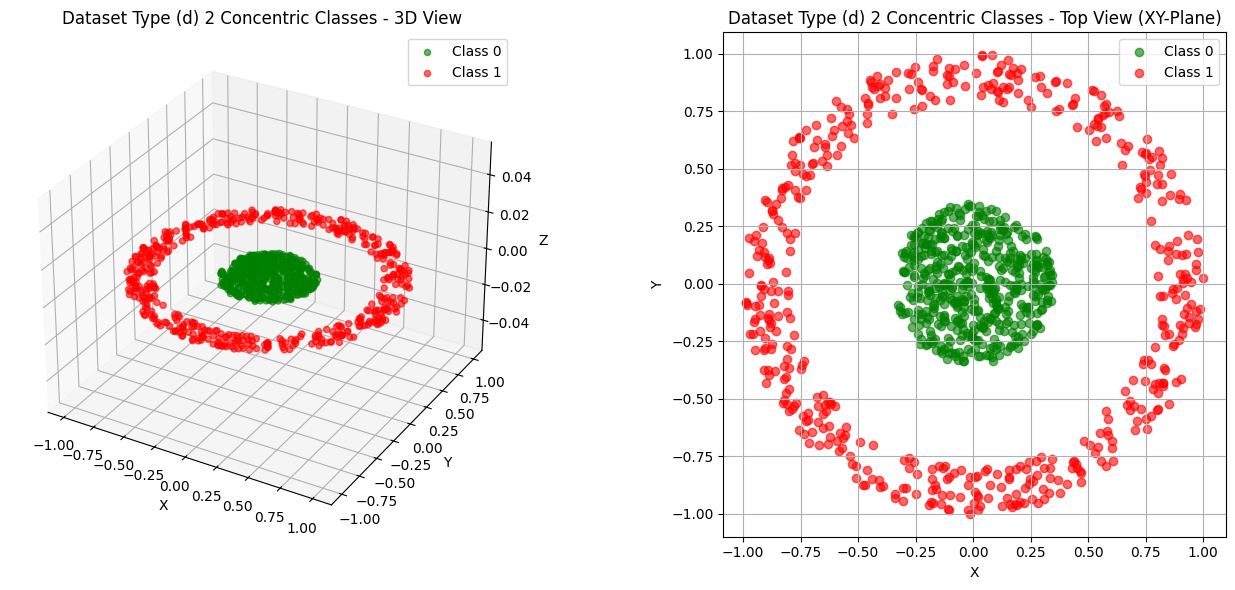


================ RUN 1/1 | loss_threshold=5e-06 | plateau_tol=1e-07 ================


----------- BEGIN TRAINING MODEL -----------

Epoch   1 | loss=0.521553
Epoch  10 | loss=0.209480
Epoch  20 | loss=0.180359
Epoch  30 | loss=0.141073
Epoch  40 | loss=0.094844
Epoch  50 | loss=0.046256
Epoch  60 | loss=0.019767
Epoch  70 | loss=0.013833
Epoch  80 | loss=0.012505
Epoch  90 | loss=0.011778
Epoch 100 | loss=0.010948
Epoch 110 | loss=0.009909
Epoch 120 | loss=0.008753
Epoch 130 | loss=0.007924
Epoch 140 | loss=0.007462
Epoch 150 | loss=0.007228
Epoch 160 | loss=0.007088
Epoch 170 | loss=0.007015
Epoch 180 | loss=0.006933
Epoch 190 | loss=0.006888
Epoch 200 | loss=0.006863
Epoch 210 | loss=0.006818
Epoch 220 | loss=0.006815
Epoch 230 | loss=0.006768
Epoch 240 | loss=0.006763
Epoch 250 | loss=0.006752
Epoch 260 | loss=0.006727
Epoch 270 | loss=0.006709
Epoch 280 | loss=0.006698
Epoch 290 | loss=0.006698
Epoch 300 | loss=0.006674
Epoch 310 | loss=0.006671
Epoch 320 | loss=0.006655
Epoch 33

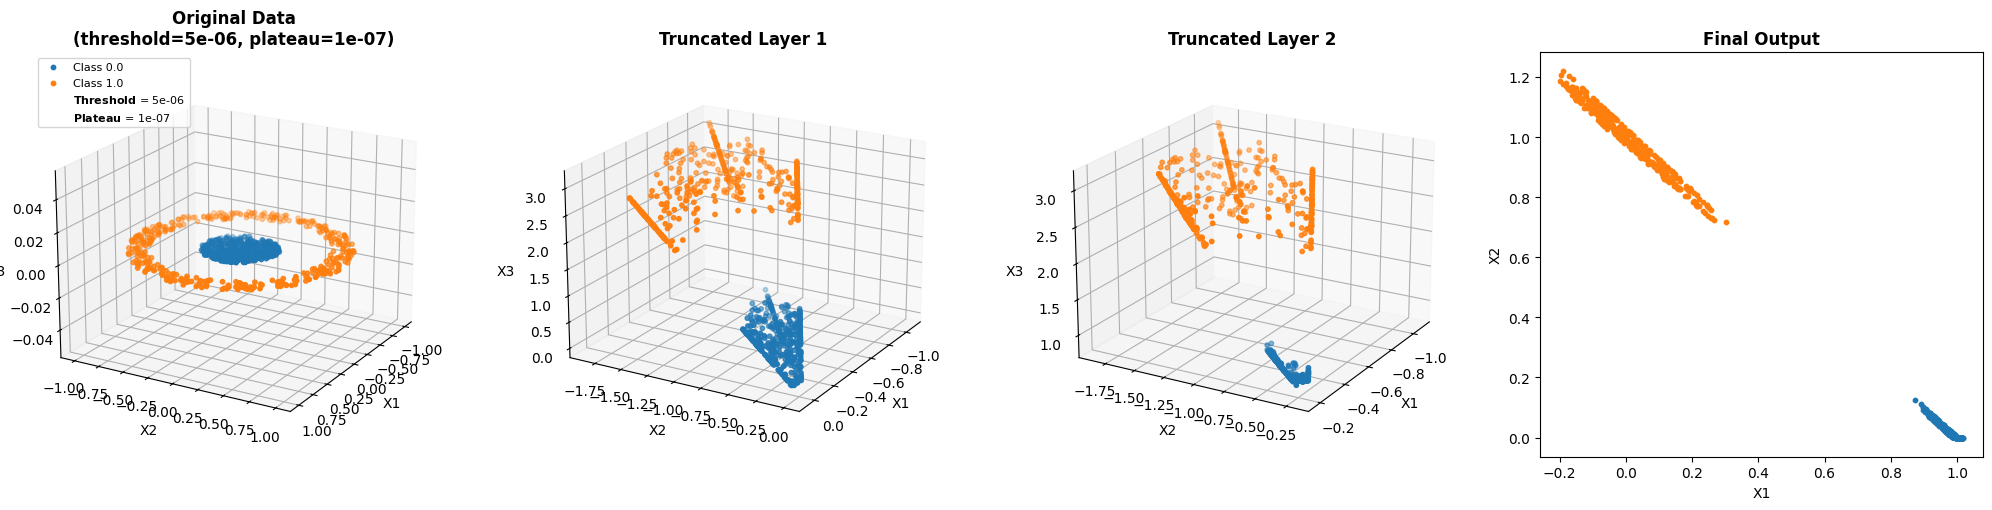

In [ ]:
run_main_pipeline('d1', loss_threshold=(5e-6), plateau_tol=1e-7) #2 Concentric Classes

> **(New) Version 2 of Dataset D using Vectors**

You have chosen: (d) 2 Concentric Classes v2
DATA: Using synthetic simplex-enclosed class (Corollary 3.2): [0, 1] | Q=2 | L=3
----------- VISUALIZING SIMPLEX-ENCLOSED DATA (Corollary 3.2) -----------



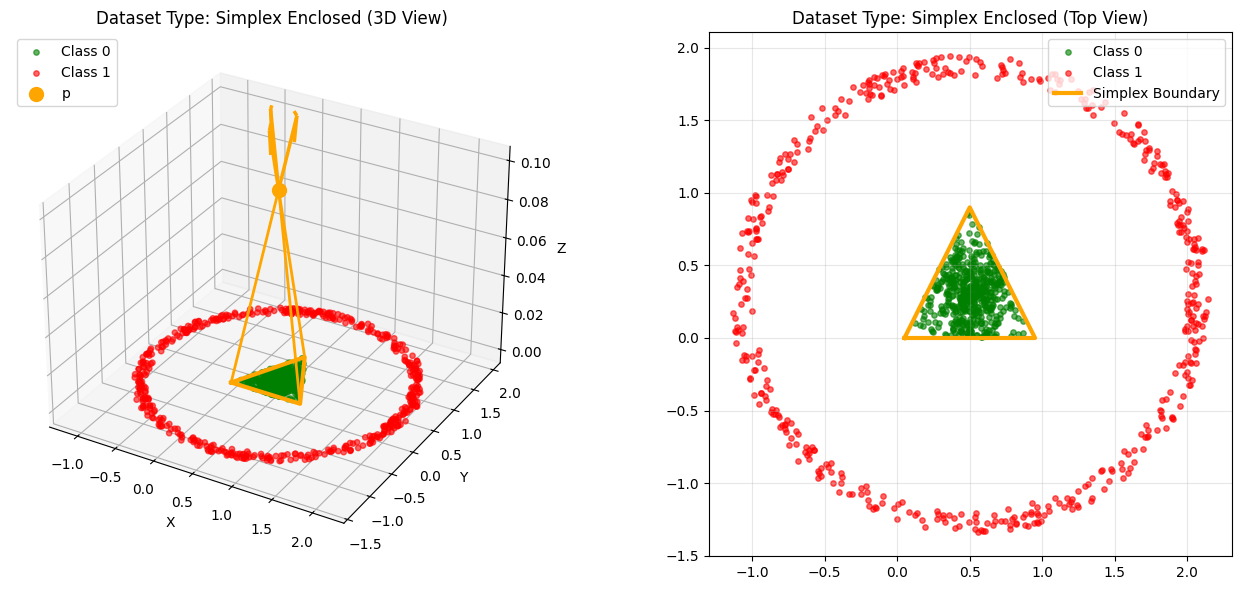


Simplex Vertices S3 (3D):
 s1 = [0.05 0.   0.  ]
 s2 = [0.95 0.   0.  ]
 s3 = [0.5 0.9 0. ]

Point p:
 p = [0.5 0.3 0.1]

Vectors v_i = p - s_i:
 v1 = [0.45 0.3  0.1 ]
 v2 = [-0.45  0.3   0.1 ]
 v3 = [ 0.  -0.6  0.1]

================ RUN 1/1 | loss_threshold=5e-06 | plateau_tol=1e-09 ================


----------- BEGIN TRAINING MODEL -----------

Epoch   1 | loss=0.744213
Epoch  10 | loss=0.245510
Epoch  20 | loss=0.226506
Epoch  30 | loss=0.195047
Epoch  40 | loss=0.138934
Epoch  50 | loss=0.061222
Epoch  60 | loss=0.017214
Epoch  70 | loss=0.005831
Epoch  80 | loss=0.004241
Epoch  90 | loss=0.003906
Epoch 100 | loss=0.003734
Epoch 110 | loss=0.003589
Epoch 120 | loss=0.003463
Epoch 130 | loss=0.003378
Epoch 140 | loss=0.003328
Epoch 150 | loss=0.003293
Epoch 160 | loss=0.003265
Epoch 170 | loss=0.003255
Epoch 180 | loss=0.003225
Epoch 190 | loss=0.003220
Epoch 200 | loss=0.003210
Epoch 210 | loss=0.003204
Epoch 220 | loss=0.003207
Epoch 230 | loss=0.003202
Epoch 240 | loss=0.00320

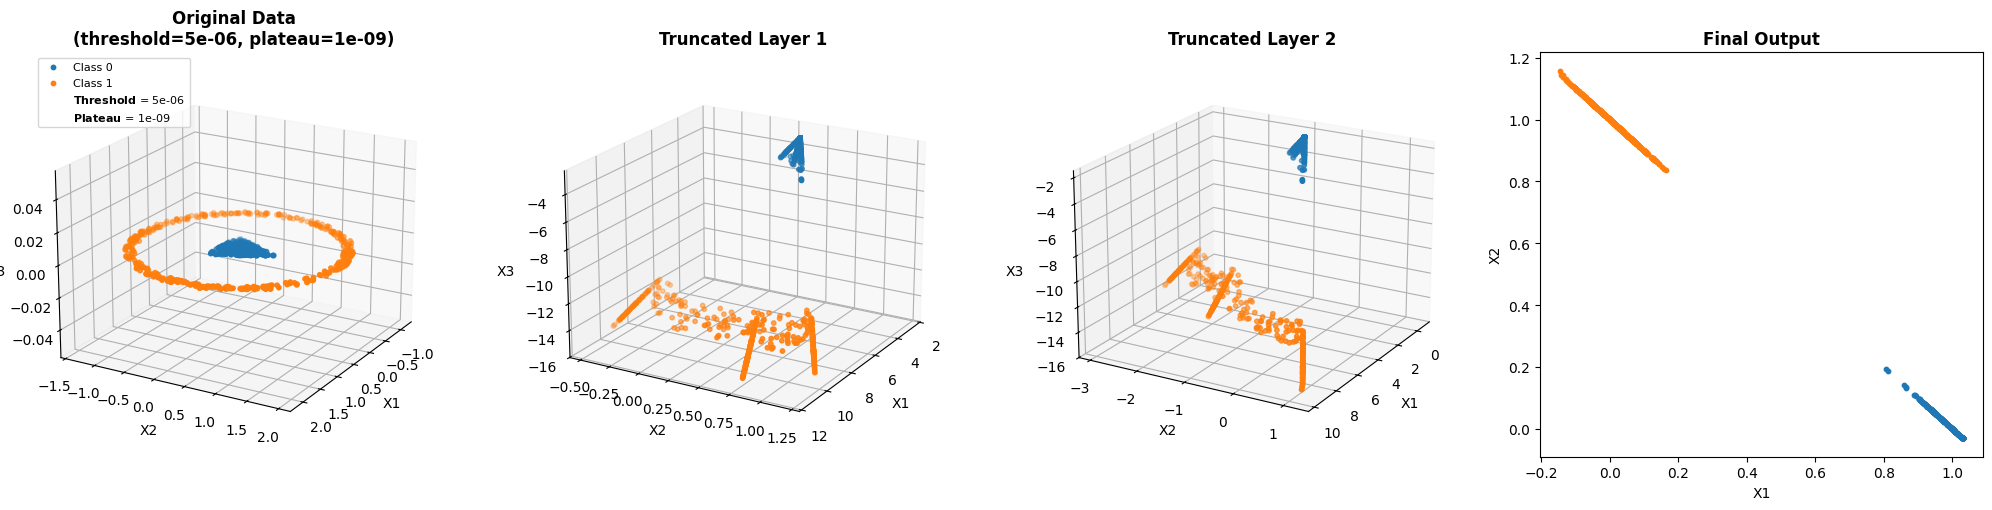

In [ ]:
run_main_pipeline('d2', loss_threshold=(5e-6), plateau_tol=1e-9) #2 Concentric Classes